# Directional OHLCV accumulation validation

This notebook tests whether Tyche's **accumulation candidate** score predicts subsequent sector-relative returns. It deliberately does not call the signal institutional buying: daily OHLCV cannot identify participant type.

The implementation matches the backend snapshot calculation: robust abnormal dollar volume, five-day close-location pressure, persistence, and volatility-adjusted quietness. Candidate observations are de-duplicated with a forward-horizon cooldown to limit overlapping outcomes.

In [1]:
import os
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from tyche_client import TycheClient

load_dotenv(override=True)  # reads TYCHE_BASE_URL / TYCHE_API_KEY from a local .env file (see .env.example)
# override=True: without it, editing .env and re-running this cell in an already-running
# kernel silently keeps the OLD value, since load_dotenv() won't clobber an env var that
# a previous run of this same cell already set -- a real bug this caused once, not hypothetical.

API_URL = os.getenv("TYCHE_BASE_URL", "http://localhost:8000")
API_KEY = os.getenv("TYCHE_API_KEY")
if not API_KEY:
    raise RuntimeError("Set TYCHE_API_KEY in a .env file before running this notebook")

INDEX = os.getenv("TYCHE_VALIDATION_INDEX", "sp500")
START = os.getenv("TYCHE_VALIDATION_START", "2021-01-01")
MAX_TICKERS = int(os.getenv("TYCHE_VALIDATION_MAX_TICKERS", "150"))
SCORE_THRESHOLD = 60.0

client = TycheClient(API_URL, API_KEY)


## Load a classified universe and daily OHLCV

The ticker cap keeps an interactive run reasonably short. Increase `TYCHE_VALIDATION_MAX_TICKERS` for the final production study.

In [2]:
universe = client.universe(index=INDEX).dropna(subset=["ticker", "sector"])
universe = (
    universe.drop_duplicates("ticker")
    .assign(_sample_key=lambda frame: pd.util.hash_pandas_object(frame["ticker"], index=False))
    .nsmallest(MAX_TICKERS, "_sample_key")
    .drop(columns="_sample_key")
)
tickers = universe["ticker"].tolist()
sector_by_ticker = universe.set_index("ticker")["sector"]

bars = client.ohlcv(tickers, start=START)
required = {"ticker", "date", "High", "Low", "Close", "Volume"}
missing = required - set(bars.columns)
if missing:
    raise RuntimeError(f"OHLCV response is missing: {sorted(missing)}")
bars = bars.dropna(subset=["High", "Low", "Close", "Volume"]).copy()
bars["sector"] = bars["ticker"].map(sector_by_ticker)
bars = bars.dropna(subset=["sector"]).sort_values(["ticker", "date"])
print(f"Loaded {bars['ticker'].nunique()} tickers and {len(bars):,} daily bars from {bars['date'].min().date()}.")


Loaded 150 tickers and 205,769 daily bars from 2021-01-04.


## Reproduce the backend score historically

In [3]:
def add_accumulation_features(group: pd.DataFrame) -> pd.DataFrame:
    ticker = group.name
    group = group.sort_values("date").copy()
    group["ticker"] = ticker
    dollar_volume = group["Close"] * group["Volume"]
    baseline = dollar_volume.shift(5).rolling(60, min_periods=20)
    baseline_median = baseline.median()
    baseline_mad = baseline.apply(
        lambda values: float((pd.Series(values) - pd.Series(values).median()).abs().median()),
        raw=True,
    )
    group["accumulation_volume_zscore"] = (
        dollar_volume.rolling(5).median() - baseline_median
    ) / (1.4826 * baseline_mad).replace(0, pd.NA)

    day_range = group["High"] - group["Low"]
    clv = ((2 * group["Close"] - group["High"] - group["Low"]) / day_range.where(day_range > 0)).fillna(0.0)
    group["accumulation_pressure_5d"] = (
        (clv * dollar_volume).rolling(5).sum() / dollar_volume.rolling(5).sum()
    )
    group["accumulation_persistence_5d"] = (clv > 0).astype(float).rolling(5).mean()

    absolute_return = group["Close"].pct_change().abs()
    recent_abs_return = absolute_return.rolling(5).mean()
    baseline_abs_return = absolute_return.shift(5).rolling(60, min_periods=20).median()
    group["accumulation_quietness_5d"] = (baseline_abs_return / recent_abs_return).clip(upper=1.0).fillna(0.0)

    activity = ((group["accumulation_volume_zscore"] - 1.0) / 2.0).clip(0.0, 1.0)
    pressure = group["accumulation_pressure_5d"].clip(0.0, 1.0)
    group["accumulation_score"] = 100 * (
        0.35 * activity
        + 0.35 * pressure
        + 0.20 * group["accumulation_persistence_5d"]
        + 0.10 * group["accumulation_quietness_5d"]
    )
    group["return_1d"] = group["Close"].pct_change()
    for horizon in (20, 60):
        group[f"forward_{horizon}d"] = group["Close"].shift(-horizon) / group["Close"] - 1
    return group

features = bars.groupby("ticker", group_keys=False).apply(add_accumulation_features).reset_index(drop=True)
features["bar_position"] = features.groupby("ticker").cumcount()
features["candidate"] = (
    (features["accumulation_score"] >= SCORE_THRESHOLD)
    & (features["accumulation_volume_zscore"] >= 1.5)
    & (features["accumulation_pressure_5d"] >= 0.10)
    & (features["accumulation_persistence_5d"] >= 0.60)
)
features[["accumulation_score", "accumulation_volume_zscore", "accumulation_pressure_5d"]].describe().round(3)


,accumulation_score,accumulation_volume_zscore,accumulation_pressure_5d
count,202192.000,202192.000,205172.000
mean,25.518,0.247,0.026
std,12.309,1.241,0.281
min,1.646,-3.640,-0.930
25%,16.499,-0.508,-0.170
50%,22.258,0.017,0.027
75%,32.677,0.716,0.225
max,94.452,40.617,0.952


## Compute sector-relative outcomes

An equal-weight sector index controls for broad sector moves. This is a stricter target than raw forward return.

In [4]:
sector_daily = (
    features.dropna(subset=["return_1d"])
    .groupby(["sector", "date"], as_index=False)["return_1d"]
    .mean()
    .sort_values(["sector", "date"])
)
sector_daily["sector_index"] = sector_daily.groupby("sector")["return_1d"].transform(lambda values: (1 + values).cumprod())
for horizon in (20, 60):
    sector_daily[f"sector_forward_{horizon}d"] = sector_daily.groupby("sector")["sector_index"].transform(
        lambda values: values.shift(-horizon) / values - 1
    )

features = features.merge(
    sector_daily[["sector", "date", "sector_forward_20d", "sector_forward_60d"]],
    on=["sector", "date"],
    how="left",
)
for horizon in (20, 60):
    features[f"excess_{horizon}d"] = features[f"forward_{horizon}d"] - features[f"sector_forward_{horizon}d"]


## Purge overlapping candidate windows and summarize lift

In [5]:
def cooldown_candidates(frame: pd.DataFrame, horizon: int) -> pd.DataFrame:
    selected = []
    for _, group in frame[frame["candidate"]].sort_values(["ticker", "date"]).groupby("ticker"):
        last_position = -horizon
        for _, row in group.iterrows():
            position = int(row["bar_position"])
            if position - last_position >= horizon:
                selected.append(row)
                last_position = position
    return pd.DataFrame(selected)

summaries = []
samples = {}
for horizon in (20, 60):
    sample = cooldown_candidates(features.dropna(subset=[f"excess_{horizon}d"]), horizon)
    samples[horizon] = sample
    eligible = features.dropna(subset=[f"excess_{horizon}d"])
    summaries.append({
        "horizon": f"{horizon}d",
        "signals": len(sample),
        "mean_excess": sample[f"excess_{horizon}d"].mean(),
        "median_excess": sample[f"excess_{horizon}d"].median(),
        "positive_rate": (sample[f"excess_{horizon}d"] > 0).mean(),
        "unconditional_mean": eligible[f"excess_{horizon}d"].mean(),
    })

summary = pd.DataFrame(summaries).set_index("horizon")
summary.style.format({
    "mean_excess": "{:.2%}",
    "median_excess": "{:.2%}",
    "positive_rate": "{:.1%}",
    "unconditional_mean": "{:.2%}",
})


,signals,mean_excess,median_excess,positive_rate,unconditional_mean
horizon,,,,,
20d,972,-0.02%,-0.41%,46.2%,-0.01%
60d,807,-0.13%,-1.08%,46.0%,0.02%


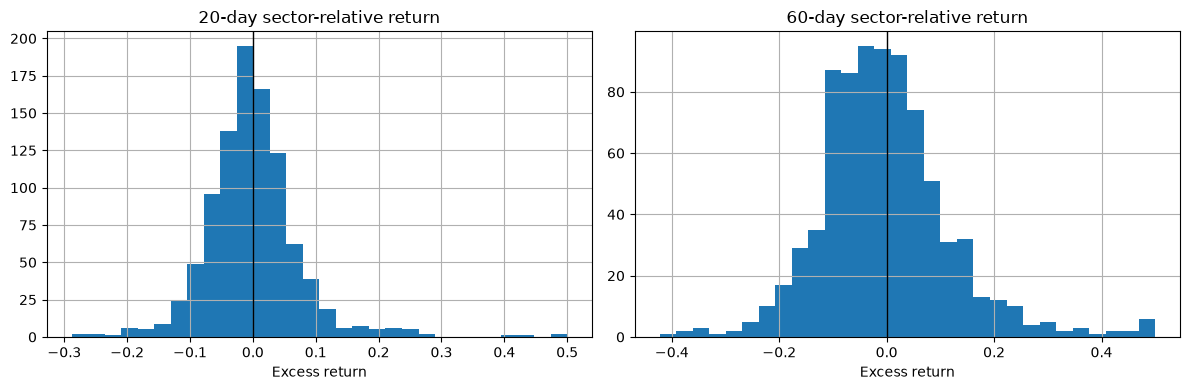

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, horizon in zip(axes, (20, 60)):
    sample = samples[horizon]
    sample[f"excess_{horizon}d"].clip(-0.5, 0.5).hist(bins=30, ax=axis)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"{horizon}-day sector-relative return")
    axis.set_xlabel("Excess return")
plt.tight_layout()


## Threshold sensitivity and walk-forward stability

A useful signal should not depend on one exact cutoff or one calendar year.

In [7]:
threshold_rows = []
for threshold in (50, 60, 70):
    subset = features[
        (features["accumulation_score"] >= threshold)
        & (features["accumulation_volume_zscore"] >= 1.5)
        & (features["accumulation_pressure_5d"] >= 0.10)
        & (features["accumulation_persistence_5d"] >= 0.60)
    ].dropna(subset=["excess_20d"])
    threshold_rows.append({
        "threshold": threshold,
        "observations": len(subset),
        "mean_excess_20d": subset["excess_20d"].mean(),
        "positive_rate_20d": (subset["excess_20d"] > 0).mean(),
    })
pd.DataFrame(threshold_rows).set_index("threshold").style.format({
    "mean_excess_20d": "{:.2%}",
    "positive_rate_20d": "{:.1%}",
})


,observations,mean_excess_20d,positive_rate_20d
threshold,,,
50,5270,0.20%,47.6%
60,2894,0.26%,47.5%
70,975,0.18%,48.9%


In [8]:
walk_forward = samples[20].assign(year=lambda frame: frame["date"].dt.year).groupby("year").agg(
    signals=("ticker", "size"),
    mean_excess_20d=("excess_20d", "mean"),
    positive_rate_20d=("excess_20d", lambda values: (values > 0).mean()),
)
walk_forward.style.format({"mean_excess_20d": "{:.2%}", "positive_rate_20d": "{:.1%}"})


,signals,mean_excess_20d,positive_rate_20d
year,,,
2021,141,-0.42%,49.6%
2022,150,0.98%,55.3%
2023,222,-0.37%,44.6%
2024,189,0.09%,43.4%
2025,169,-0.68%,40.8%
2026,101,0.68%,45.5%


## Causal box-range features

A box is a geometric state, not a bullish label. Boundaries use only prior closes, so a future breakout cannot contaminate its own resistance level. Stable containment, flat slope, repeated boundary tests, compressed volatility, and box duration are measured separately from directional accumulation.

In [9]:
HORIZON = 20
SWING_THRESHOLD = 0.10
BOX_WINDOWS = (20, 40, 60)

def slope_displacement(values) -> float:
    x = np.arange(len(values), dtype=float)
    y = np.asarray(values, dtype=float)
    centered = x - x.mean()
    denominator = centered @ centered
    return 0.0 if denominator == 0 else float((centered @ (y - y.mean())) / denominator * len(y))

def add_box_and_swing_features(group: pd.DataFrame) -> pd.DataFrame:
    ticker = group.name
    group = group.sort_values("date").copy()
    group["ticker"] = ticker
    close = group["Close"]
    previous_close = close.shift(1)
    true_range = pd.concat([
        group["High"] - group["Low"],
        (group["High"] - previous_close).abs(),
        (group["Low"] - previous_close).abs(),
    ], axis=1).max(axis=1)
    atr = true_range.rolling(14, min_periods=10).mean()
    returns = close.pct_change()
    volatility_ratio = returns.rolling(10, min_periods=5).std() / returns.shift(10).rolling(60, min_periods=20).std()

    for window in BOX_WINDOWS:
        history = close.shift(1).rolling(window, min_periods=window)
        lower = history.quantile(0.10)
        upper = history.quantile(0.90)
        width = upper - lower
        slope = close.shift(1).rolling(window, min_periods=window).apply(slope_displacement, raw=True)
        inside = close.between(lower, upper)
        containment = inside.astype(float).rolling(10, min_periods=5).mean()
        lower_touch = ((close - lower).abs() <= 0.5 * atr).astype(float).rolling(window, min_periods=window // 2).sum()
        upper_touch = ((close - upper).abs() <= 0.5 * atr).astype(float).rolling(window, min_periods=window // 2).sum()
        width_atr = width / atr
        slope_ratio = slope.abs() / width.replace(0, pd.NA)
        loose_box = (containment >= 0.70) & (slope_ratio <= 0.50) & (width_atr <= 8.0) & (volatility_ratio <= 1.25)
        streak_group = (~loose_box).cumsum()

        group[f"box_lower_{window}"] = lower
        group[f"box_upper_{window}"] = upper
        group[f"box_containment_{window}"] = containment
        group[f"box_slope_ratio_{window}"] = slope_ratio
        group[f"box_width_atr_{window}"] = width_atr
        group[f"box_lower_touches_{window}"] = lower_touch
        group[f"box_upper_touches_{window}"] = upper_touch
        group[f"box_volatility_ratio_{window}"] = volatility_ratio
        group[f"box_days_{window}"] = loose_box.groupby(streak_group).cumcount().add(1).where(loose_box, 0)
        group[f"box_score_{window}"] = 100 * (
            0.30 * containment.clip(0, 1)
            + 0.25 * (1 - slope_ratio).clip(0, 1)
            + 0.25 * (1 - width_atr / 8).clip(0, 1)
            + 0.20 * (1 - volatility_ratio / 1.25).clip(0, 1)
        )

    future_high = pd.concat([group["High"].shift(-day) for day in range(1, HORIZON + 1)], axis=1)
    future_low = pd.concat([group["Low"].shift(-day) for day in range(1, HORIZON + 1)], axis=1)
    complete = future_high.notna().sum(axis=1).eq(HORIZON)
    upside_by_day = future_high.div(close, axis=0) - 1
    swing_by_day = upside_by_day.ge(SWING_THRESHOLD)
    group["max_upside_excursion_20d"] = (future_high.max(axis=1) / close - 1).where(complete)
    group["max_downside_excursion_20d"] = (future_low.min(axis=1) / close - 1).where(complete)
    group["swing_hit_20d"] = group["max_upside_excursion_20d"].ge(SWING_THRESHOLD).where(complete)
    first_hit = np.argmax(swing_by_day.to_numpy(), axis=1) + 1
    group["days_to_swing"] = pd.Series(first_hit, index=group.index).where(swing_by_day.any(axis=1) & complete)
    return group

features = features.groupby("ticker", group_keys=False).apply(add_box_and_swing_features).reset_index(drop=True)
assert features["box_score_40"].notna().any() and features["max_upside_excursion_20d"].notna().any()
features[["box_score_20", "box_score_40", "box_score_60", "max_upside_excursion_20d"]].describe().round(3)


,box_score_20,box_score_40,box_score_60,max_upside_excursion_20d
count,201298.000,199808.000,196828.000,202788.000
mean,43.596,40.378,38.253,0.071
std,16.319,17.488,17.685,0.078
min,0.000,0.000,0.000,-0.251
25%,30.985,26.506,24.004,0.025
50%,42.037,39.883,38.524,0.054
75%,55.811,54.015,51.894,0.096
max,91.600,90.088,87.072,3.506


## Purged walk-forward optimizer

The target is a 10% intraperiod upside swing within 20 sessions. Mean, median, a fixed-bin mode, endpoint return, hit rate, time-to-swing, and adverse excursion are reported. The optimizer uses hit rate and robust excursion statistics; it does not optimize the unstable raw mode.

In [10]:
PARAMETER_NAMES = (
    "window", "min_containment", "max_slope_ratio", "max_width_atr",
    "min_box_days", "accumulation_threshold", "min_volume_zscore",
)
PARAMETER_GRID = [
    dict(zip(PARAMETER_NAMES, values))
    for values in product(
        BOX_WINDOWS,
        (0.50, 0.70),
        (0.50, 1.00),
        (6.0, 10.0),
        (1, 3),
        (30.0, 50.0),
        (-0.5, 0.5),
    )
]

def binned_mode(values: pd.Series, width: float = 0.02) -> float:
    values = values.dropna()
    if values.empty:
        return float("nan")
    modes = (values / width).round().mul(width).mode()
    return float(modes.iloc[0])

def signal_mask(frame: pd.DataFrame, params: dict) -> pd.Series:
    window = int(params["window"])
    return (
        (frame[f"box_containment_{window}"] >= params["min_containment"])
        & (frame[f"box_slope_ratio_{window}"] <= params["max_slope_ratio"])
        & (frame[f"box_width_atr_{window}"] <= params["max_width_atr"])
        & (frame[f"box_lower_touches_{window}"] >= 1)
        & (frame[f"box_upper_touches_{window}"] >= 1)
        & (frame[f"box_volatility_ratio_{window}"] <= 1.25)
        & (frame[f"box_days_{window}"] >= params["min_box_days"])
        & (frame["accumulation_score"] >= params["accumulation_threshold"])
        & (frame["accumulation_volume_zscore"] >= params["min_volume_zscore"])
        & (frame["accumulation_pressure_5d"] >= 0.00)
        & (frame["accumulation_persistence_5d"] >= 0.40)
    )

def select_non_overlapping(frame: pd.DataFrame, params: dict) -> pd.DataFrame:
    candidates = frame[
        signal_mask(frame, params) & frame["max_upside_excursion_20d"].notna()
    ].sort_values(["ticker", "date"])
    selected = []
    for _, group in candidates.groupby("ticker"):
        last_position = -HORIZON
        for index, position in zip(group.index, group["bar_position"].astype(int)):
            if position - last_position >= HORIZON:
                selected.append(index)
                last_position = position
    return candidates.loc[selected]

def excursion_metrics(sample: pd.DataFrame) -> dict:
    if sample.empty:
        return {"signals": 0, "objective": float("-inf")}
    upside = sample["max_upside_excursion_20d"]
    downside = sample["max_downside_excursion_20d"]
    endpoint = sample["forward_20d"]
    hit_rate = float(sample["swing_hit_20d"].mean())
    median_upside = float(upside.median())
    robust_mean_upside = float(upside.clip(upper=0.50).mean())
    median_downside = float(downside.median())
    return {
        "signals": len(sample),
        "swing_hit_rate": hit_rate,
        "mean_upside": float(upside.mean()),
        "median_upside": median_upside,
        "mode_upside_2pct_bin": binned_mode(upside),
        "mean_endpoint_return": float(endpoint.mean()),
        "median_endpoint_return": float(endpoint.median()),
        "mode_endpoint_2pct_bin": binned_mode(endpoint),
        "median_downside": median_downside,
        "median_days_to_swing": float(sample.loc[sample["swing_hit_20d"].eq(True), "days_to_swing"].median()),
        "objective": hit_rate + median_upside + 0.5 * robust_mean_upside - 0.5 * abs(median_downside),
    }


In [11]:
labeled = features.dropna(subset=["max_upside_excursion_20d"]).copy()
years = sorted(labeled["date"].dt.year.unique())
validation_years = years[2:]
fold_rows = []
out_of_sample = []

for year in validation_years:
    validation_start = pd.Timestamp(year=year, month=1, day=1)
    validation_end = pd.Timestamp(year=year + 1, month=1, day=1)
    train = labeled[labeled["date"] < validation_start - pd.Timedelta(days=40)]
    validation = labeled[(labeled["date"] >= validation_start) & (labeled["date"] < validation_end)]

    best = None
    for params in PARAMETER_GRID:
        train_sample = select_non_overlapping(train, params)
        metrics = excursion_metrics(train_sample)
        if metrics["signals"] < 30:
            continue
        if best is None or metrics["objective"] > best[0]:
            best = (metrics["objective"], params, metrics)
    if best is None:
        continue

    _, best_params, train_metrics = best
    validation_sample = select_non_overlapping(validation, best_params)
    validation_metrics = excursion_metrics(validation_sample)
    if not validation_sample.empty:
        out_of_sample.append(validation_sample.assign(validation_year=year))
    fold_rows.append({
        "validation_year": year,
        **best_params,
        "train_signals": train_metrics["signals"],
        "train_objective": train_metrics["objective"],
        "validation_signals": validation_metrics["signals"],
        "validation_swing_hit_rate": validation_metrics.get("swing_hit_rate", float("nan")),
        "validation_median_upside": validation_metrics.get("median_upside", float("nan")),
        "validation_median_downside": validation_metrics.get("median_downside", float("nan")),
    })

fold_results = pd.DataFrame(fold_rows)
oos_sample = pd.concat(out_of_sample, ignore_index=True) if out_of_sample else pd.DataFrame()
oos_metrics = excursion_metrics(oos_sample)
assert not fold_results.empty, "No parameter set produced enough training signals"


In [12]:
fold_results.style.format({
    "train_objective": "{:.3f}",
    "validation_swing_hit_rate": "{:.1%}",
    "validation_median_upside": "{:.2%}",
    "validation_median_downside": "{:.2%}",
})


,validation_year,window,min_containment,max_slope_ratio,max_width_atr,min_box_days,accumulation_threshold,min_volume_zscore,train_signals,train_objective,validation_signals,validation_swing_hit_rate,validation_median_upside,validation_median_downside
0,2023,20,0.500000,0.500000,6.000000,1,50.000000,-0.500000,58,0.361,40,25.0%,4.75%,-3.21%
1,2024,20,0.500000,0.500000,6.000000,1,50.000000,-0.500000,96,0.341,34,11.8%,3.61%,-5.68%
2,2025,40,0.500000,0.500000,6.000000,3,50.000000,-0.500000,122,0.328,28,14.3%,3.54%,-4.15%
3,2026,40,0.500000,0.500000,6.000000,3,50.000000,-0.500000,150,0.297,6,66.7%,12.02%,-8.27%


In [13]:
pd.Series(oos_metrics, name="purged walk-forward OOS").to_frame().style.format({
    "purged walk-forward OOS": lambda value: f"{value:.2%}" if isinstance(value, float) and abs(value) < 1 else f"{value:.2f}",
})


,purged walk-forward OOS
signals,108.00
swing_hit_rate,20.37%
mean_upside,7.17%
median_upside,4.21%
mode_upside_2pct_bin,4.00%
mean_endpoint_return,1.39%
median_endpoint_return,0.57%
mode_endpoint_2pct_bin,0.00%
median_downside,-4.56%
median_days_to_swing,14.00


In [14]:
baseline_sample = labeled[
    labeled["date"].dt.year.isin(fold_results["validation_year"])
    & labeled["bar_position"].mod(HORIZON).eq(0)
]
baseline_metrics = excursion_metrics(baseline_sample)
comparison_metrics = [
    "signals", "swing_hit_rate", "mean_upside", "median_upside",
    "mode_upside_2pct_bin", "mean_endpoint_return", "median_endpoint_return",
    "mode_endpoint_2pct_bin", "median_downside", "median_days_to_swing",
]
comparison = pd.DataFrame(
    [oos_metrics, baseline_metrics],
    index=["optimized box + flow", "every-20th-bar baseline"],
)[comparison_metrics]
comparison["swing_hit_rate_lift"] = comparison["swing_hit_rate"] - baseline_metrics["swing_hit_rate"]
comparison.style.format({
    "signals": "{:.0f}",
    "swing_hit_rate": "{:.2%}",
    "mean_upside": "{:.2%}",
    "median_upside": "{:.2%}",
    "mode_upside_2pct_bin": "{:.2%}",
    "mean_endpoint_return": "{:.2%}",
    "median_endpoint_return": "{:.2%}",
    "mode_endpoint_2pct_bin": "{:.2%}",
    "median_downside": "{:.2%}",
    "median_days_to_swing": "{:.1f}",
    "swing_hit_rate_lift": "{:+.2%}",
})


,signals,swing_hit_rate,mean_upside,median_upside,mode_upside_2pct_bin,mean_endpoint_return,median_endpoint_return,mode_endpoint_2pct_bin,median_downside,median_days_to_swing,swing_hit_rate_lift
optimized box + flow,108,20.37%,7.17%,4.21%,4.00%,1.39%,0.57%,0.00%,-4.56%,14.0,-1.26%
every-20th-bar baseline,6397,21.64%,6.97%,5.09%,2.00%,1.16%,0.84%,0.00%,-4.55%,12.0,+0.00%


## Interpretation

- Judge the detector by purged out-of-sample swing hit rate, median upside excursion, downside excursion, and stability of selected parameters—not the best training score.
- Require positive lift over the every-20th-bar baseline; a high raw hit rate alone is not evidence of predictive value.
- The fixed 2% bin mode is descriptive only. Continuous-return modes change materially with bin width.
- Treat low signal counts, unstable parameters, or concentration in one year as rejection evidence.
- Earnings, offerings, M&A, and index-rebalance exclusions still require event flags from the data API before production use.
- Even a validated box-plus-flow signal remains suspected accumulation, not proof of institutional ownership.